# downloading cell ranger

In [ ]:
curl -o cellranger-atac-2.2.0.tar.gz "https://cf.10xgenomics.com/releases/cell-atac/cellranger-atac-2.2.0.tar.gz?Expires=1775081849&Key-Pair-Id=APKAI7S6A5RYOXBWRPDA&Signature=HRU6PMzKAWRoHYxRKIyDUBy7Xn0oGAwvng2YA~ie4c3Tf3QHf7-mSwJmzRH8RTVPWgzKjZtybyjSEItjbM5vYgL9BNs7WaKkVJ36helc82hznSWYVbKy2u68G7e2PV7C82X3HW2daSF6KQr2WjMK1bnRyLSBm3Lr9CqEo82f-iD~jpza21KKx1jkjYr3ZN6fmyri1ZnVBEqyhcPggD0RFiq0Jp~7hDA8rFkcJSGPrvfstsu4FoAuTiU2HplNPShi~EoSz8EY2UTlPlN55PDDah6ep-LajDFtsXMqBaMDItaj5OR8aVCC~Q5KczaxBU7UuyUpz~q4uZngOJdhAnDalg__"


# file extraction

In [ ]:
tar -xvzf cellranger-atac-2.2.0.tar.gz

# human genome reference file

In [ ]:
curl -O "https://cf.10xgenomics.com/supp/cell-arc/refdata-cellranger-arc-GRCh38-2024-A.tar.gz"

In [ ]:
tar -xvzf refdata-cellranger-arc-GRCh38-2024-A.tar.gz 
GENOME="refdata-cellranger-atac-GRCh38-1.2.0/fasta/genome.fa"

# Prepare working directories


In [ ]:
mkdir chromatin_results
mkdir chromatin_results/AD 
mkdir chromatin_results/MB


#  Rename ONLY required files


In [ ]:
Use genomic reads:


mv AD/SRR26205321_2.fastq.gz AD/AD_R1.fastq.gz
mv AD/SRR26205321_4.fastq.gz AD/AD_R2.fastq.gz

mv MB/SRR18324551_2.fastq.gz MB/MB_R1.fastq.gz
mv MB/SRR18324551_4.fastq.gz MB/MB_R2.fastq.gz


#  Quality check

In [ ]:
bash
fastqc AD/AD_R1.fastq.gz AD/AD_R2.fastq.gz
fastqc MB/MB_R1.fastq.gz MB/MB_R2.fastq.gz


#  Alignment (VERY IMPORTANT)

In [ ]:
Use genome from your reference:

bash
GENOME="refdata-cellranger-atac-GRCh38-1.2.0/fasta/genome.fa"


Run:

bash
bwa mem -t 8 ~/refdata-cellranger-arc-GRCh38-2024-A/fasta/genome.fa AD/AD21_R1.fastq.gz AD/AD21_R2.fastq.gz > chromatin_results/AD/AD.sam
bwa mem -t 8 ~/refdata-cellranger-arc-GRCh38-2024-A/fasta/genome.fa MB/MB48_R1.fastq.gz MB/MB48_R2.fastq.gz > chromatin_results/MB/MB.sam


#  Convert + sort + index

In [ ]:
bash
samtools view -Sb chromatin_results/AD/19_AD.sam | samtools sort -o chromatin_results/AD/19_AD_sorted.bam
samtools view -Sb chromatin_results/MB/48_MB.sam | samtools sort -o chromatin_results/MB/48_MB_sorted.bam


samtools index results/AD/19_AD_sorted.bam
samtools index results/MB/48_MB_sorted.bam


#  Remove duplicates (CRITICAL for ATAC)

In [ ]:
samtools sort -n -o chromatin_results/AD/19_AD_name_sorted.bam chromatin_results/AD/20_AD_sorted.bam
samtools sort -n -o chromatin_results/MB/48_MB_name_sorted.bam chromatin_results/MB/48_MB_sorted.bam

In [ ]:
samtools fixmate -m chromatin_results/AD/19_AD_name_sorted.bam chromatin_results/AD/20_AD_fixmate.bam
samtools fixmate -m chromatin_results/MB/48_MB_name_sorted.bam chromatin_results/MB/48_MB_fixmate.bam

In [ ]:
samtools sort -o chromatin_results/AD/19_AD_fixmate_sorted.bam chromatin_results/AD/20_AD_fixmate.bam
samtools sort -o chromatin_results/MB/48_MB_fixmate_sorted.bam chromatin_results/MB/48_MB_fixmate.bam

In [ ]:
samtools markdup -r chromatin_results/AD/19_AD_fixmate_sorted.bam chromatin_results/AD/20_AD_dedup.bam
samtools markdup -r chromatin_results/MB/48_MB_fixmate_sorted.bam chromatin_results/MB/48_MB_dedup.bam

In [ ]:
samtools index chromatin_results/AD/19_AD_sorted.bam
samtools index chromatin_results/MB/48_MB_sorted.bam

 # Checking Bedtools Installation

In [ ]:

conda list | grep bedtools
which bedtools

#  Installing Bedtools (if missing)

In [ ]:
conda install -c bioconda bedtools
# OR
sudo apt install bedtools

 # Merging BAM Files (Combine Replicates)

In [ ]:
AD BAM Merge
samtools merge chromatin_results/AD/AD_merged_dedup.bam \
chromatin_results/AD/19_AD_dedup.bam \
chromatin_results/AD/20_AD_dedup.bam \
chromatin_results/AD/21_AD_dedup.bam \
chromatin_results/AD/22_AD_dedup.bam


In [ ]:
MB BAM Merge
samtools merge chromatin_results/MB/MB_merged_dedup.bam \
chromatin_results/MB/MB_48_dedup.bam \
chromatin_results/MB/MB_49_dedup.bam \
chromatin_results/MB/MB_50_dedup.bam \
chromatin_results/MB/MB_51_dedup.bam

# Sorting and Indexing BAM Files

In [ ]:
samtools sort -o chromatin_results/AD/AD_merged_sorted.bam chromatin_results/AD/AD_merged_dedup.bam
samtools index chromatin_results/AD/AD_merged_sorted.bam

samtools sort -o chromatin_results/MB/MB_merged_sorted.bam chromatin_results/MB/MB_merged_dedup.bam
samtools index chromatin_results/MB/MB_merged_sorted.bam

# Peak calling (core step)

In [ ]:
sudo apt update
sudo apt install build-essential python3-dev
pip install python
pip install --no-binary :all: MACS2
pip install MACS2
conda create -n macs2_env python=3.10
conda activate macs2_env
pip install MACS2


In [ ]:
macs2 callpeak -t chromatin_results/AD/AD_merged_sorted.bam \
-f BAMPE -g hs -n AD_merged --outdir chromatin_results/AD

In [ ]:
macs2 callpeak -t chromatin_results/MB/MB_merged_sorted.bam \
-f BAMPE -g hs -n MB_merged --outdir chromatin_results/MB

In [ ]:
if (!requireNamespace("BiocManager"))
    install.packages("BiocManager")

BiocManager::install("DiffBind")
BiocManager::install("DESeq2")

library(DiffBind)
library(DESeq2)

# Create samples.csv

SampleID,Condition,Replicate,bamReads,Peaks,PeakCaller
AD1,AD,1,results/AD1/AD1_dedup.bam,results/AD1/AD1_peaks.narrowPeak,macs
AD2,AD,2,results/AD2/AD2_dedup.bam,results/AD2/AD2_peaks.narrowPeak,macs
AD3,AD,3,results/AD3/AD3_dedup.bam,results/AD3/AD3_peaks.narrowPeak,macs
AD4,AD,4,results/AD4/AD4_dedup.bam,results/AD4/AD4_peaks.narrowPeak,macs
MB1,MB,1,results/MB1/MB1_dedup.bam,results/MB1/MB1_peaks.narrowPeak,macs
MB2,MB,2,results/MB2/MB2_dedup.bam,results/MB2/MB2_peaks.narrowPeak,macs
MB3,MB,3,results/MB3/MB3_dedup.bam,results/MB3/MB3_peaks.narrowPeak,macs
MB4,MB,4,results/MB4/MB4_dedup.bam,results/MB4/MB4_peaks.narrowPeak,macs


library(DiffBind)

db <- dba(sampleSheet="samples.csv")
db
db <- dba.count(db)
db <- dba.contrast(db,
                   categories=DBA_CONDITION)

dba.show(db,bContrasts=TRUE)

db <- dba.analyze(db,
                  method=DBA_DESEQ2)

diff <- dba.report(db,
                   method=DBA_DESEQ2,
                   th=0.05)

write.csv(as.data.frame(diff),
          "DifferentialPeaks.csv")

write.table(as.data.frame(diff),
            "DifferentialPeaks.bed",
            sep="\t",
            quote=FALSE,
            row.names=FALSE)



###########################################################################################################################################

conda activate macs2_env

annotatePeaks.pl \
/home/ankita/chromatin_results/DifferentialPeaks.bed \
hg38 \
> /home/ankita/chromatin_results/DifferentialPeakAnnotation.txt


cut -f16 /home/ankita/chromatin_results/DifferentialPeakAnnotation.txt | \
tail -n +2 | sort | uniq > \
/home/ankita/chromatin_results/differential_gene_list.txt


#motif 
findMotifsGenome.pl \
/home/ankita/chromatin_results/Differential_Peaks.bed \
hg38 \
/home/ankita/chromatin_results/Differential_Motif_Results \
-size given \
-mknown

In [ ]:
###################################################################################################################################################################################

# Identify SHARED chromatin regions

In [ ]:
conda install -c bioconda bedtools
sudo apt update
sudo apt install bedtools


In [ ]:
bedtools intersect -a chromatin_results/AD/AD_merged_peaks.narrowPeak \
-b chromatin_results/MB/MB_merged_peaks.narrowPeak \
-wa -wb > chromatin_results/shared_AD_MB.bed

# HOMER Installation & Setup

In [ ]:
cd ~/software
git clone https://github.com/tfthomas/homer.git homer
cd homer
perl configureHomer.pl -install
or
conda install -c bioconda homer
perl configureHomer.pl -install hg38

# Peak Annotation (HOMER)

In [ ]:
annotatePeaks.pl chromatin_results/shared_AD_MB.bed hg38 \
> chromatin_results/shared_annotation.txt

# Motif Analysis

In [ ]:
findMotifsGenome.pl chromatin_results/shared_AD_MB.bed hg38 chromatin_results/motifs/

# check annotation file

In [ ]:
head chromatin_results/shared_annotation_hg38.txt


# Count All Genomic Regions

In [ ]:
cut -f8 chromatin_results/shared_annotation_hg38.txt | sort | uniq -c > chromatin_results/region_counts.txt

# Extract Promoter Peaks

In [ ]:
grep "promoter-TSS" chromatin_results/shared_annotation_hg38.txt > chromatin_results/promoter_peaks.txt

# Count Promoter Peaks

In [ ]:
grep -c "promoter-TSS" chromatin_results/shared_annotation_hg38.txt


output 1500

# Count Total Peaks

In [ ]:
wc -l chromatin_results/shared_annotation_hg38.txt

output 10901

# percentage 

In [ ]:
echo "scale=2; 1500*100/10900" | bc

In [6]:
df = pd.read_csv("/home/ankita/chromatin_results/shared_annotation_hg38.txt", sep="\t")

In [7]:
import os
os.getcwd()

'/home/ankita/Documents'

# Simplify Annotation Names

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/ankita/chromatin_results/shared_annotation_hg38.txt", sep="\t")

# Simplify categories
def simplify(x):
    x = str(x).lower()
    if "promoter" in x:
        return "Promoter"
    elif "intron" in x:
        return "Intron"
    elif "exon" in x:
        return "Exon"
    elif "intergenic" in x:
        return "Intergenic"
    else:
        return "Other"

df['Simple_Annotation'] = df['Annotation'].apply(simplify)

counts = df['Simple_Annotation'].value_counts()
print(counts)

Simple_Annotation
Promoter      7584
Intergenic    1333
Intron        1233
Exon           642
Other          108
Name: count, dtype: int64


 # Pie chart

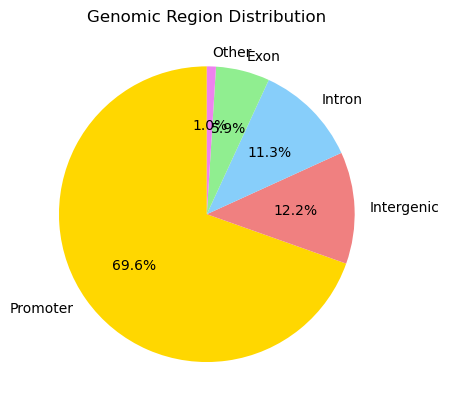

In [13]:
plt.figure()

colors = ['gold', 'lightcoral', 'lightskyblue', 'lightgreen', 'violet']

counts.plot.pie(
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Genomic Region Distribution")
plt.ylabel("")
plt.show()

# bar chart

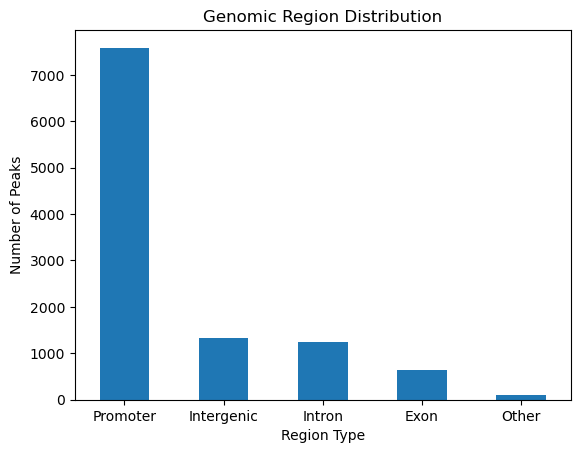

In [14]:
plt.figure()

counts.plot(kind='bar')

plt.title("Genomic Region Distribution")
plt.xlabel("Region Type")
plt.ylabel("Number of Peaks")
plt.xticks(rotation=0)

plt.show()